#  使用示例

## 功能

这个模块暂时有三个作用，第一个作用，快速设置绘图风格，一方面可以快速设置采用流萤主题配色的个人偏好风格，另一方面可以快速设置具有“Science”期刊中图片特色的科研绘图风格。第二个作用，生成流萤主题的配色。第三个作用，可以快速绘制最一般最常用的绘图，将代码从数行浓缩为一行。

## 说明

这个说明应该配合下面的具体代码使用。

首先导入必要的模块，然后用```plt.rcParams.update```进行绘图风格设置。特别注意两点，模块内的代码被修改后，需要**重启内核**；风格设置由```ypu.ysy_settings```切换为```ypu.science_settings```后，也需要**重启内核**（注意当前版本用这个风格时，```ypu.plot```的```scatter```绘制功能会出问题）。此外，风格设置有一些参数可以传递，具体见说明文档。第二段代码展示了设置风格后的绘图效果。

然后，我们可以用```ypu.firefly```来获得流萤主题颜色，函数具体用法可以参考说明文档。第三和第四段代码展示了一些具体用法。

最后，```ypu.plot```给出了一个替代我们最常用的```plt.plot```的快捷方法（指的是绘制第二段代码那样的图）。用法上，可以单一绘图，参数传递与```plt.plot```类似，但是强制要求传递```legend_name```参数。绘制多个图时，需在参数```y```的位置传递一个包含要绘制的各个y的**元组**（预计新版本更新后，会兼容数组类型），同时参数```legend_name```也要传递对应长度的由字符串构成的**元组**。其它参数可以参考说明文档。此外，要绘制散点图，可以将```plot_type```改为```'scatter'```。第五和第六段代码给出了一些示例。

In [1]:
# 导入必要的库
import numpy as np
import matplotlib.pyplot as plt
import ysy_plot_utils as ypu

# 绘图风格设置
plt.rcParams.update(ypu.ysy_settings())

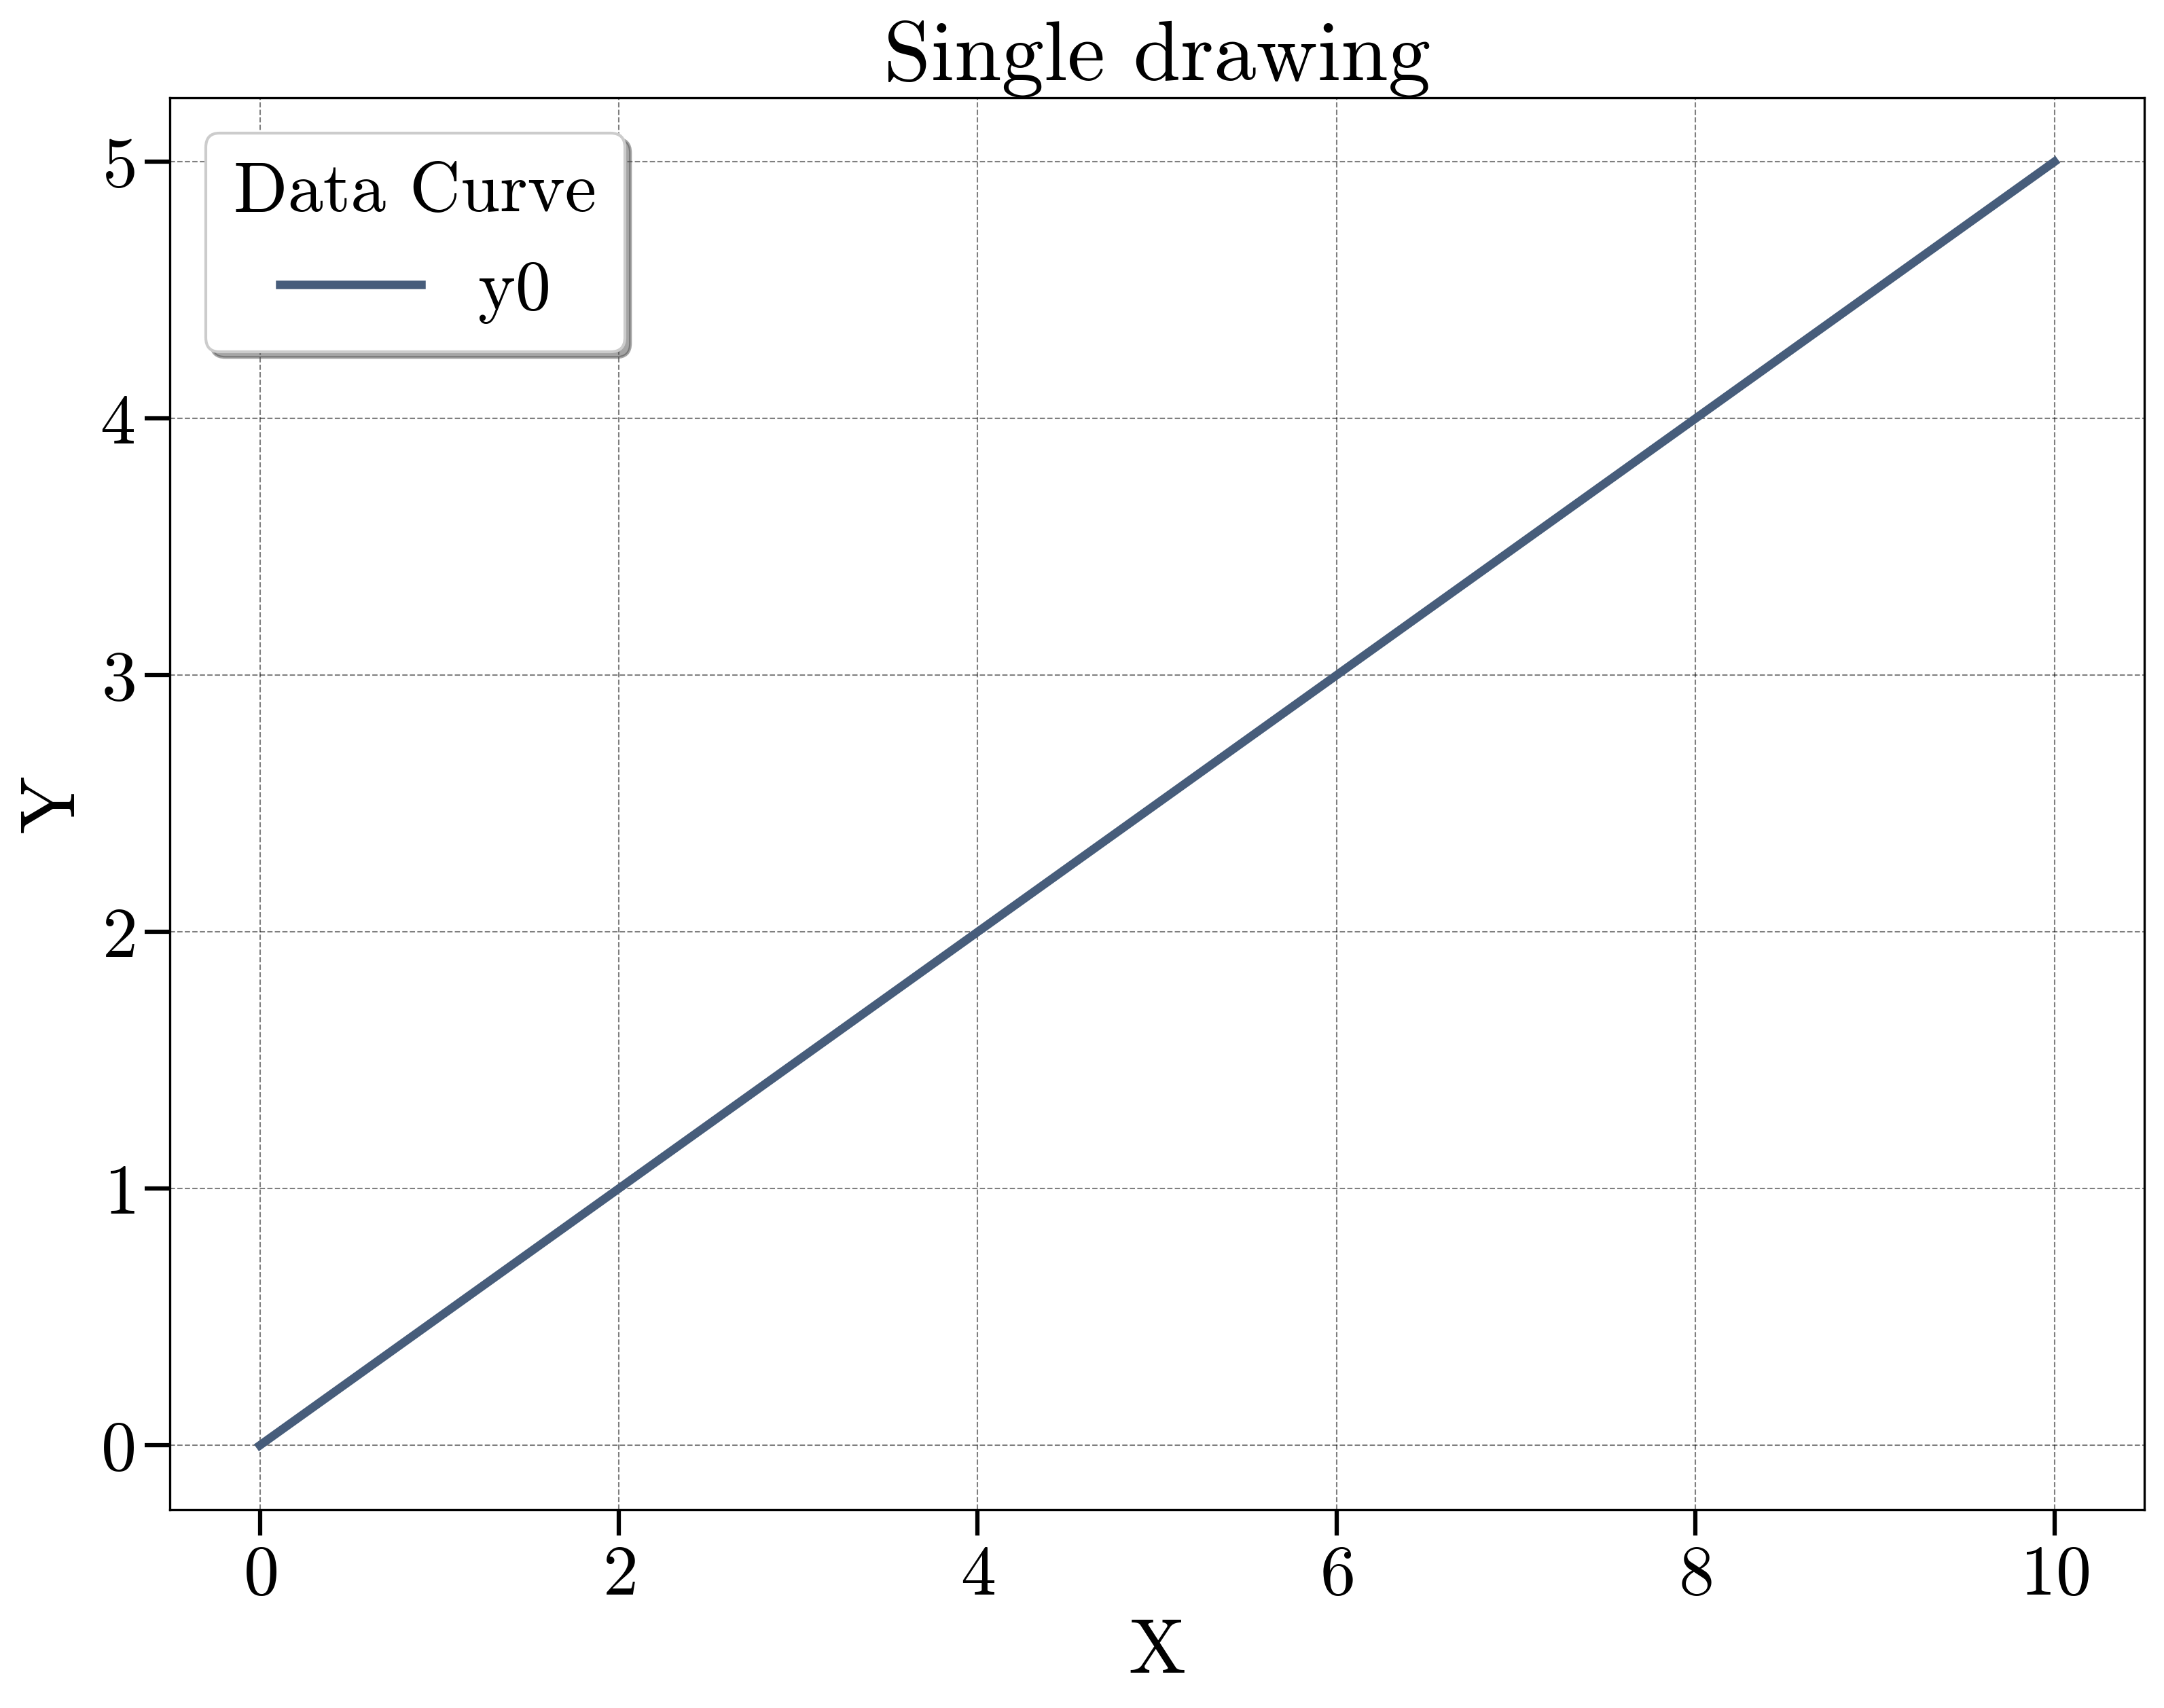

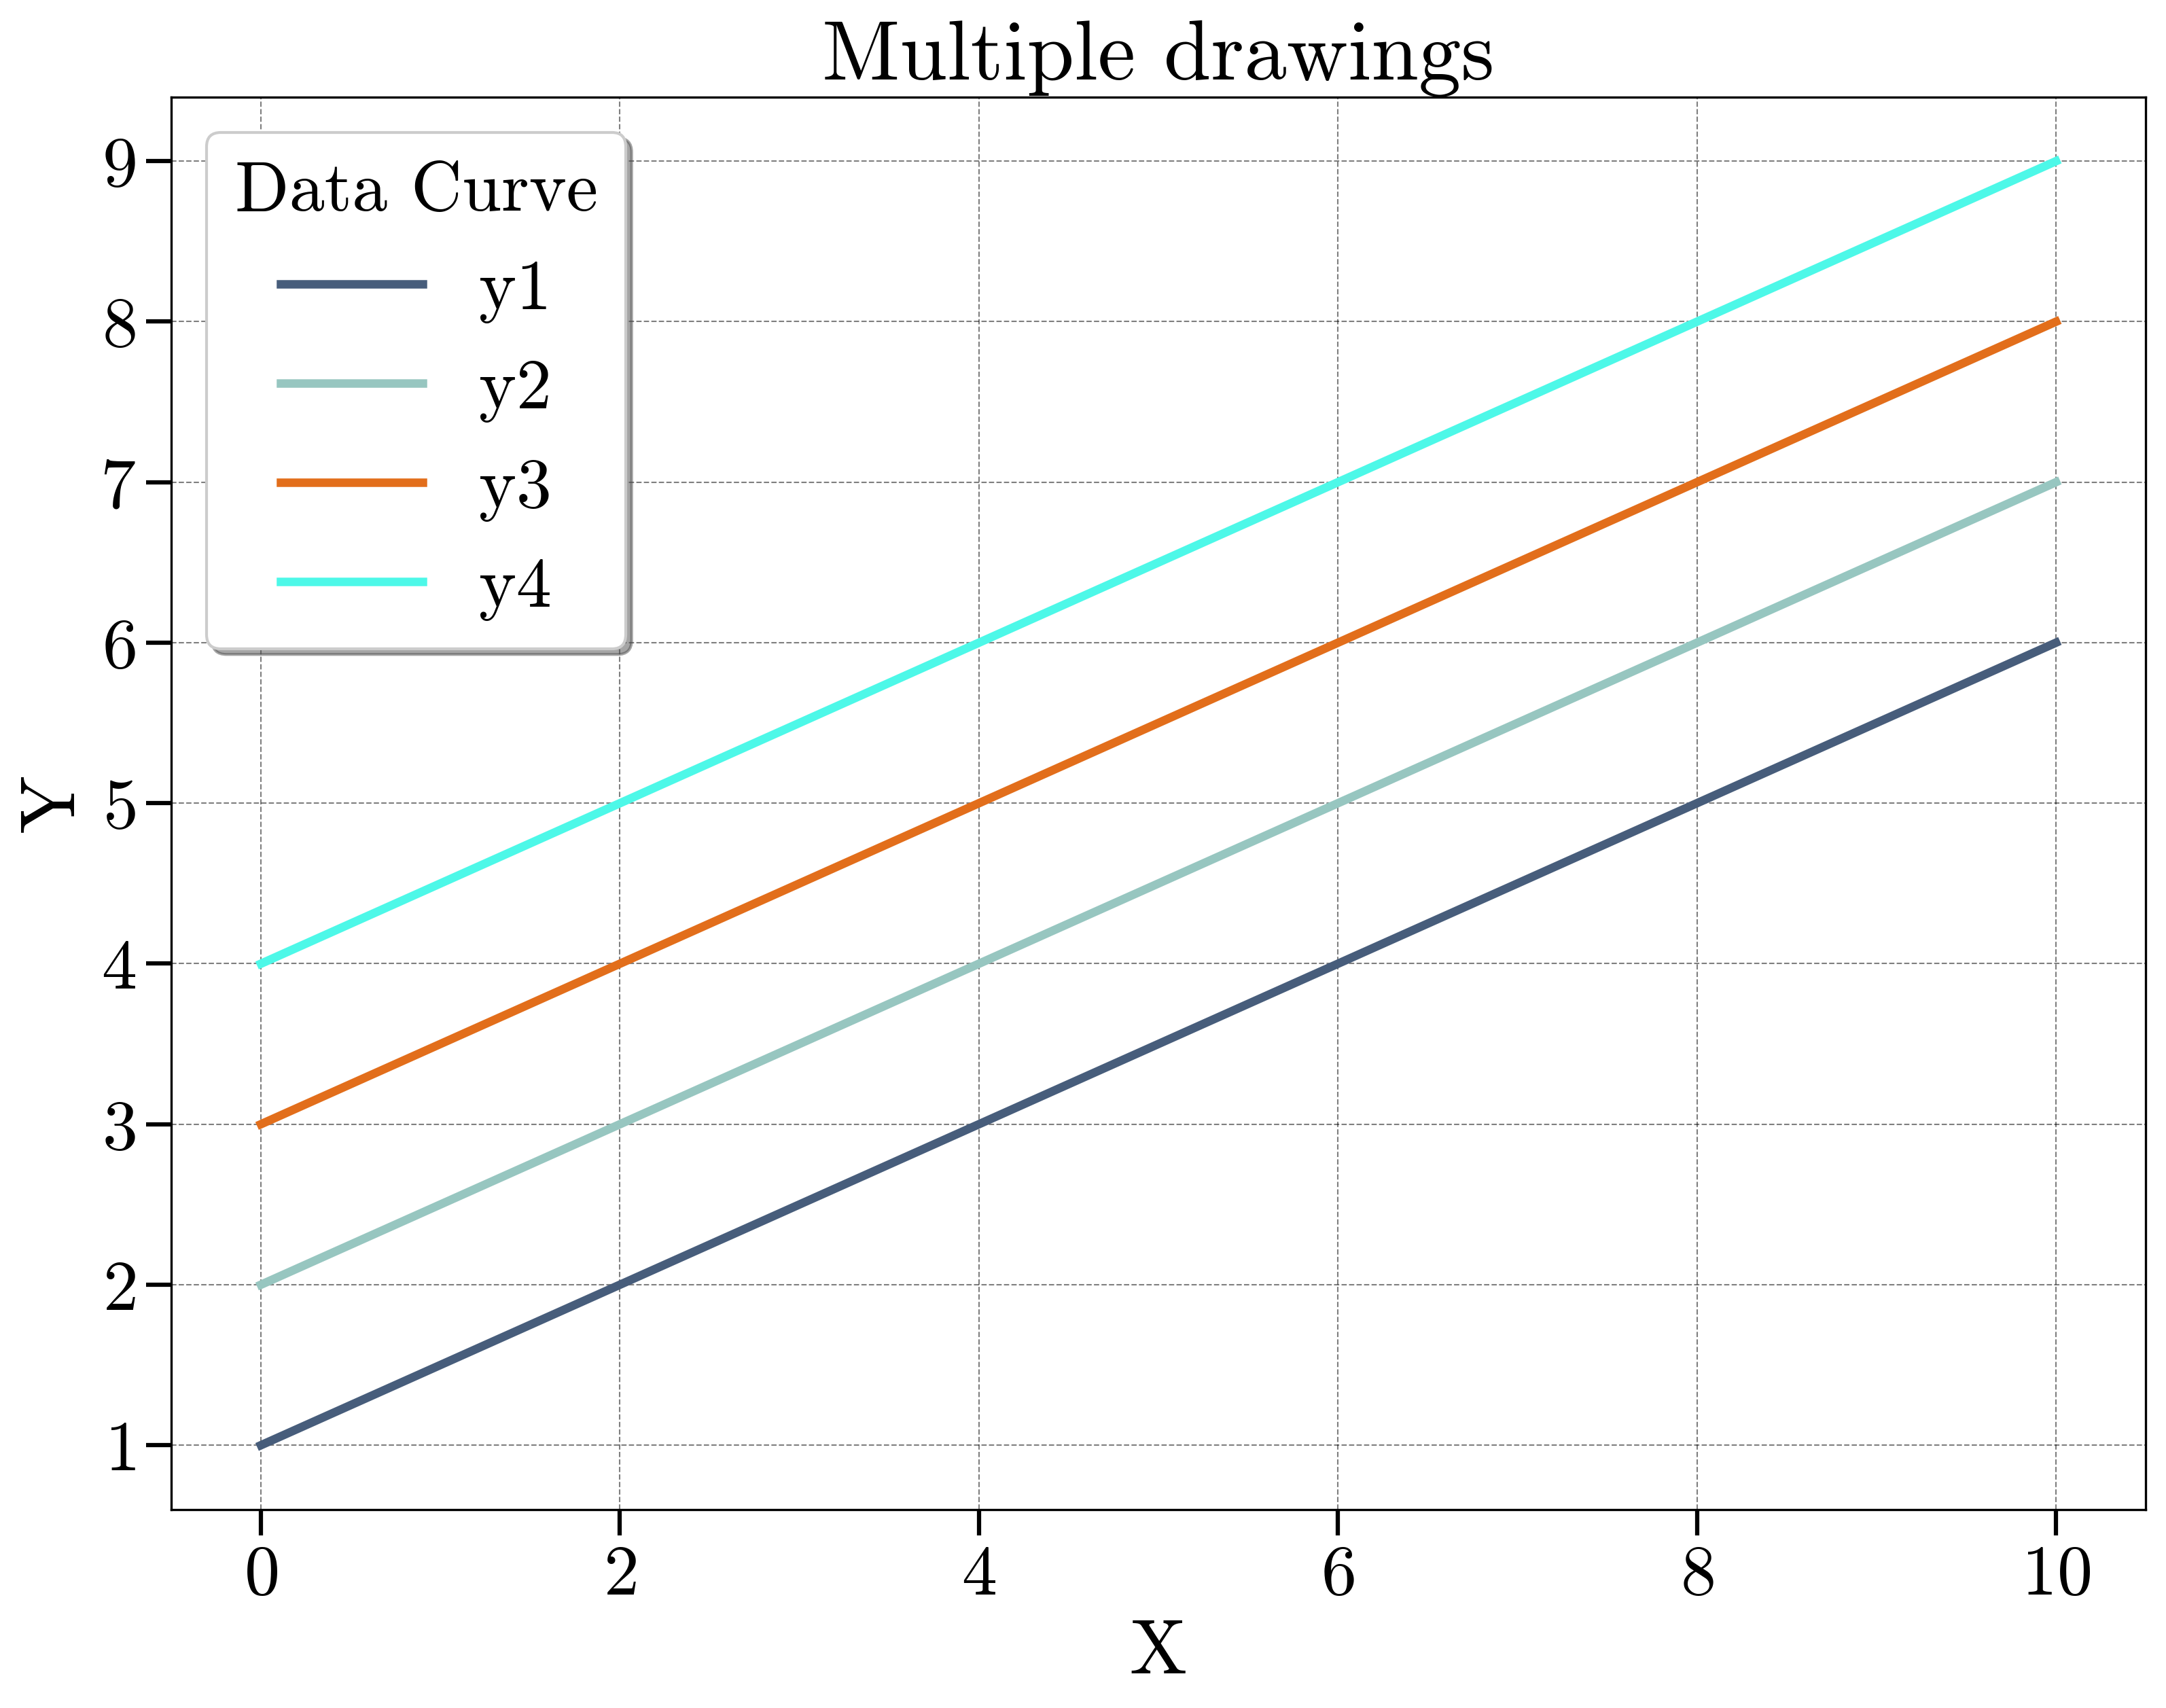

In [2]:
# 生成数据
x = np.linspace(0, 10, 1000)
y0 = 0.5 * x
y1 = 0.5 * x + 1
y2 = 0.5 * x + 2
y3 = 0.5 * x + 3
y4 = 0.5 * x + 4

# 单一绘图
plt.figure()
plt.plot(x, y0, label='y0')
plt.legend(title='Data Curve')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Single drawing')
plt.show()

# 多个绘图
plt.figure()
plt.plot(x, y1, label='y1')
plt.plot(x, y2, label='y2')
plt.plot(x, y3, label='y3')
plt.plot(x, y4, label='y4')
plt.legend(title='Data Curve')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Multiple drawings')
plt.show()

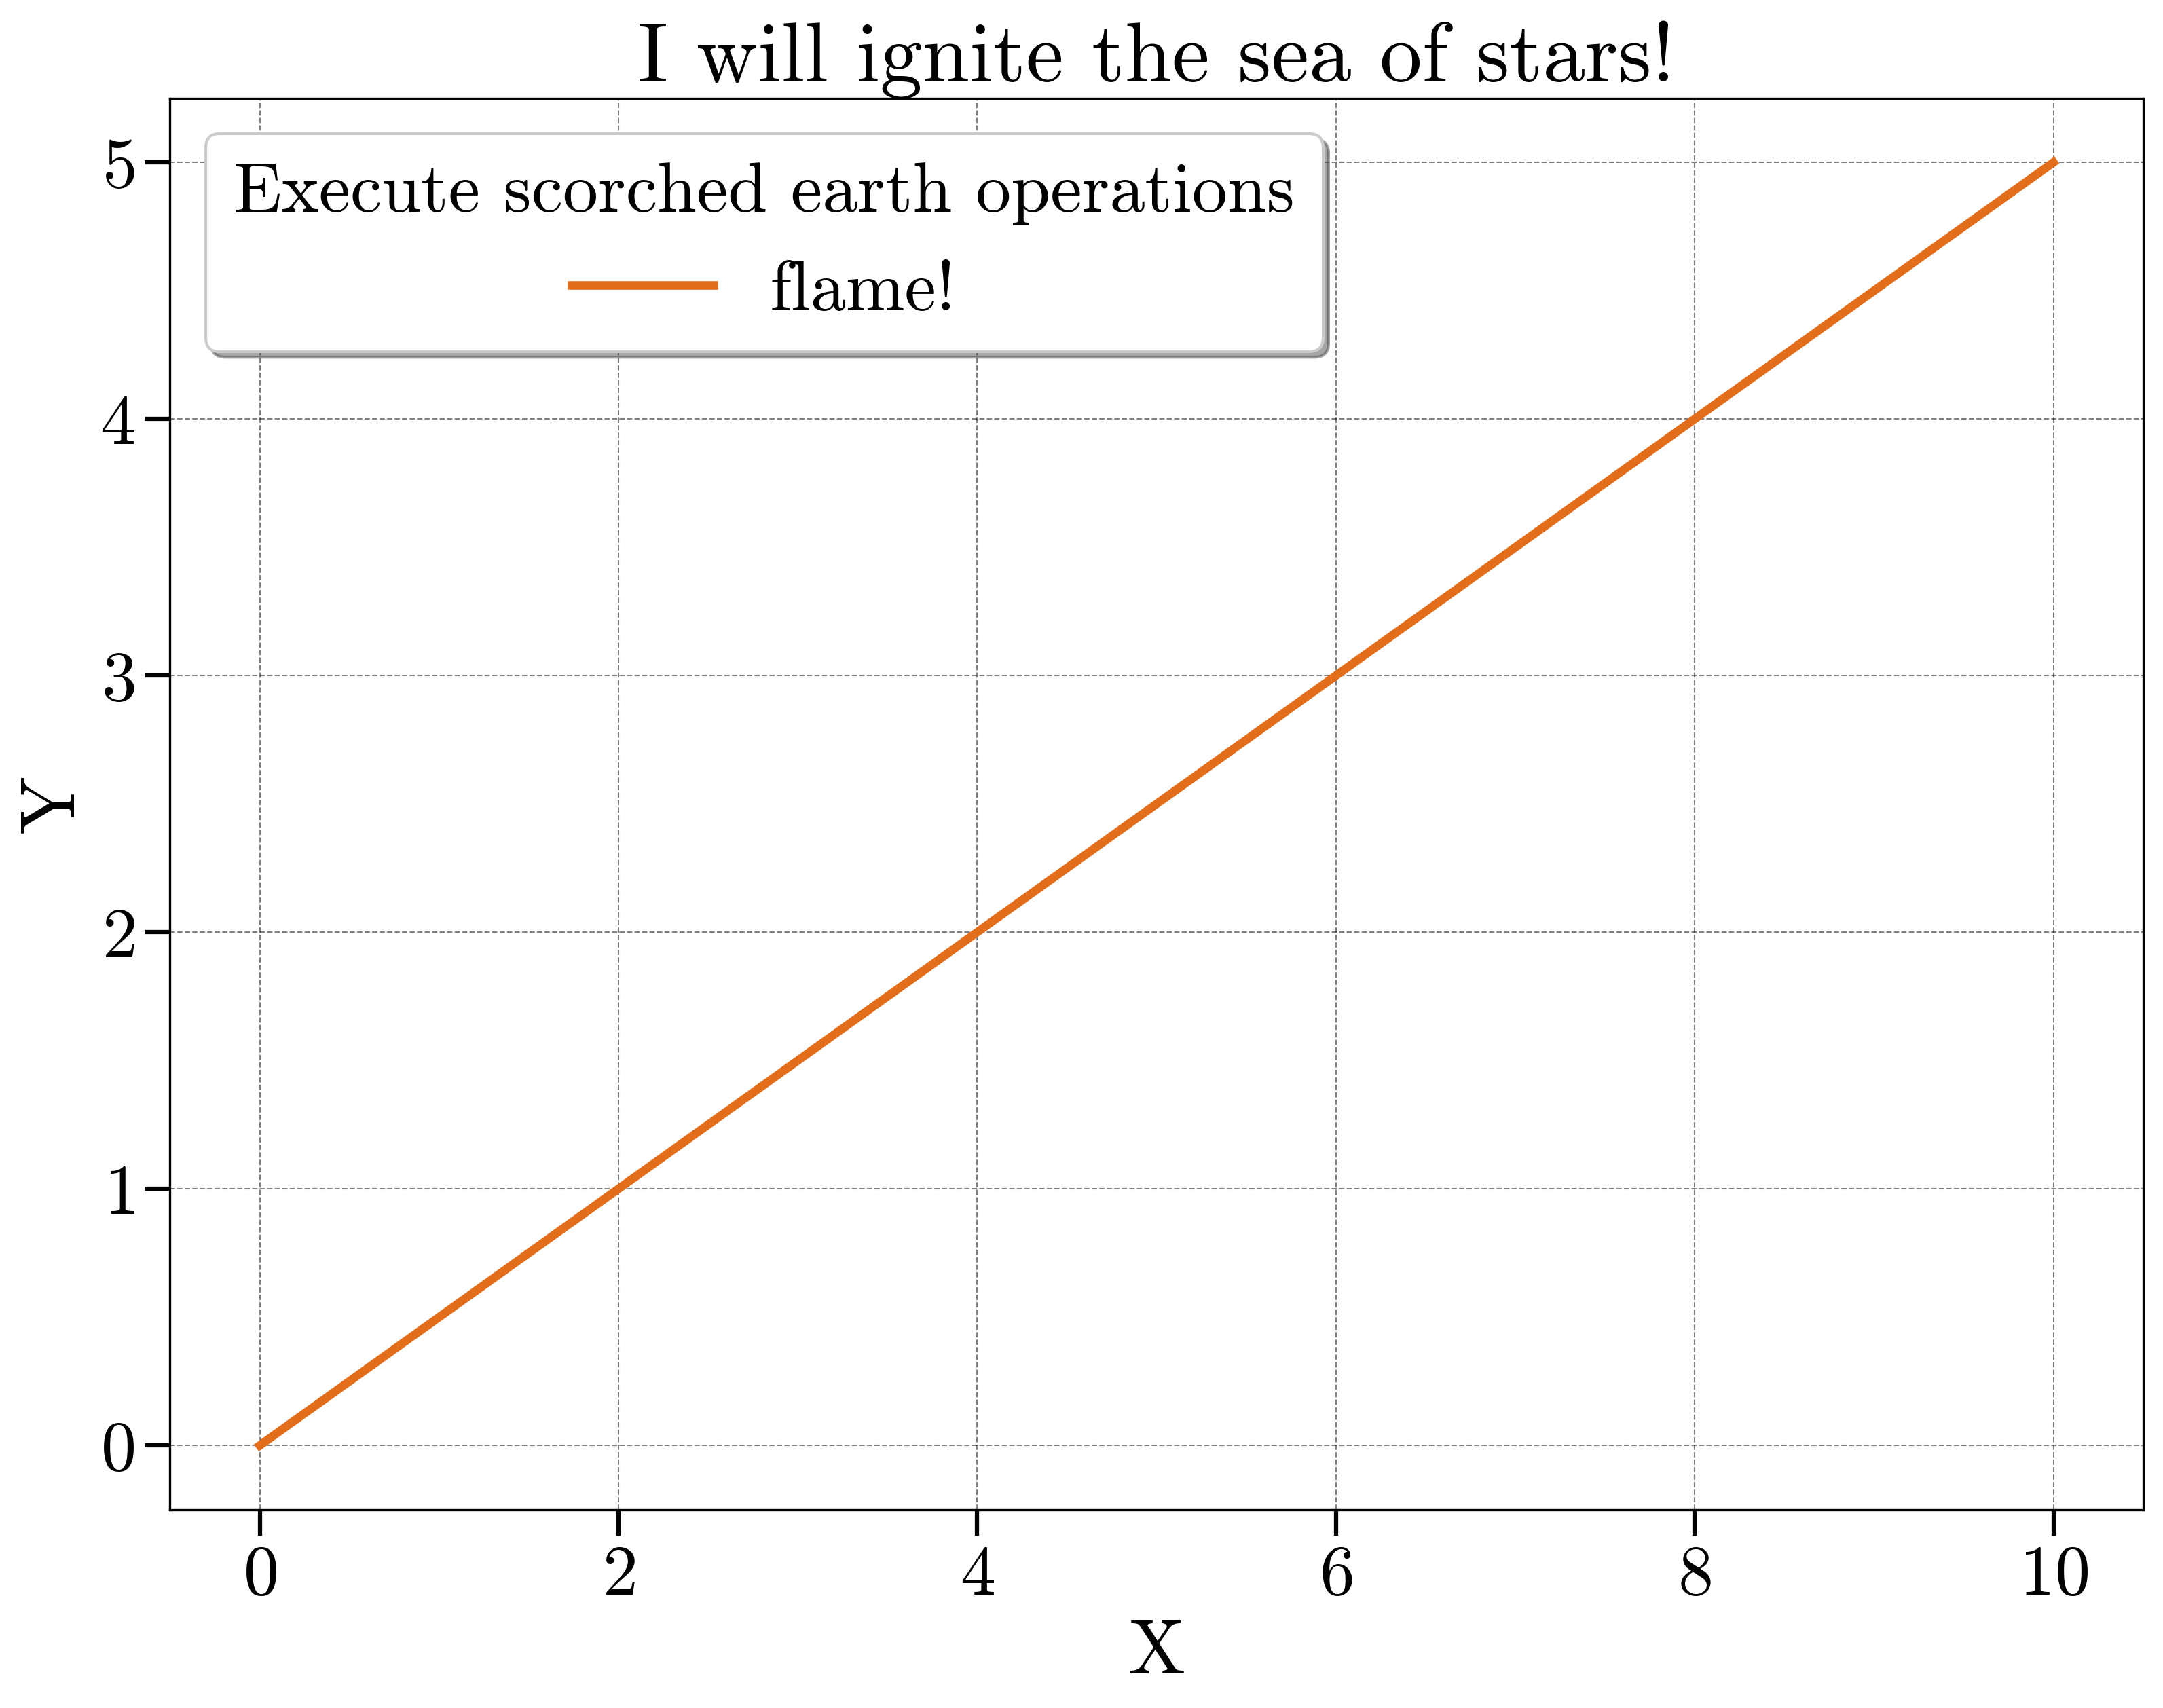

In [3]:
# 获得流萤主题配色中的某个颜色（例如将上面第一个绘图的线条改为萨姆火焰的颜色）
plt.figure()
plt.plot(x, y0, label='flame!', color=ypu.firefly('fred'))
plt.legend(title='Execute scorched earth operations')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('I will ignite the sea of stars!')
plt.show()

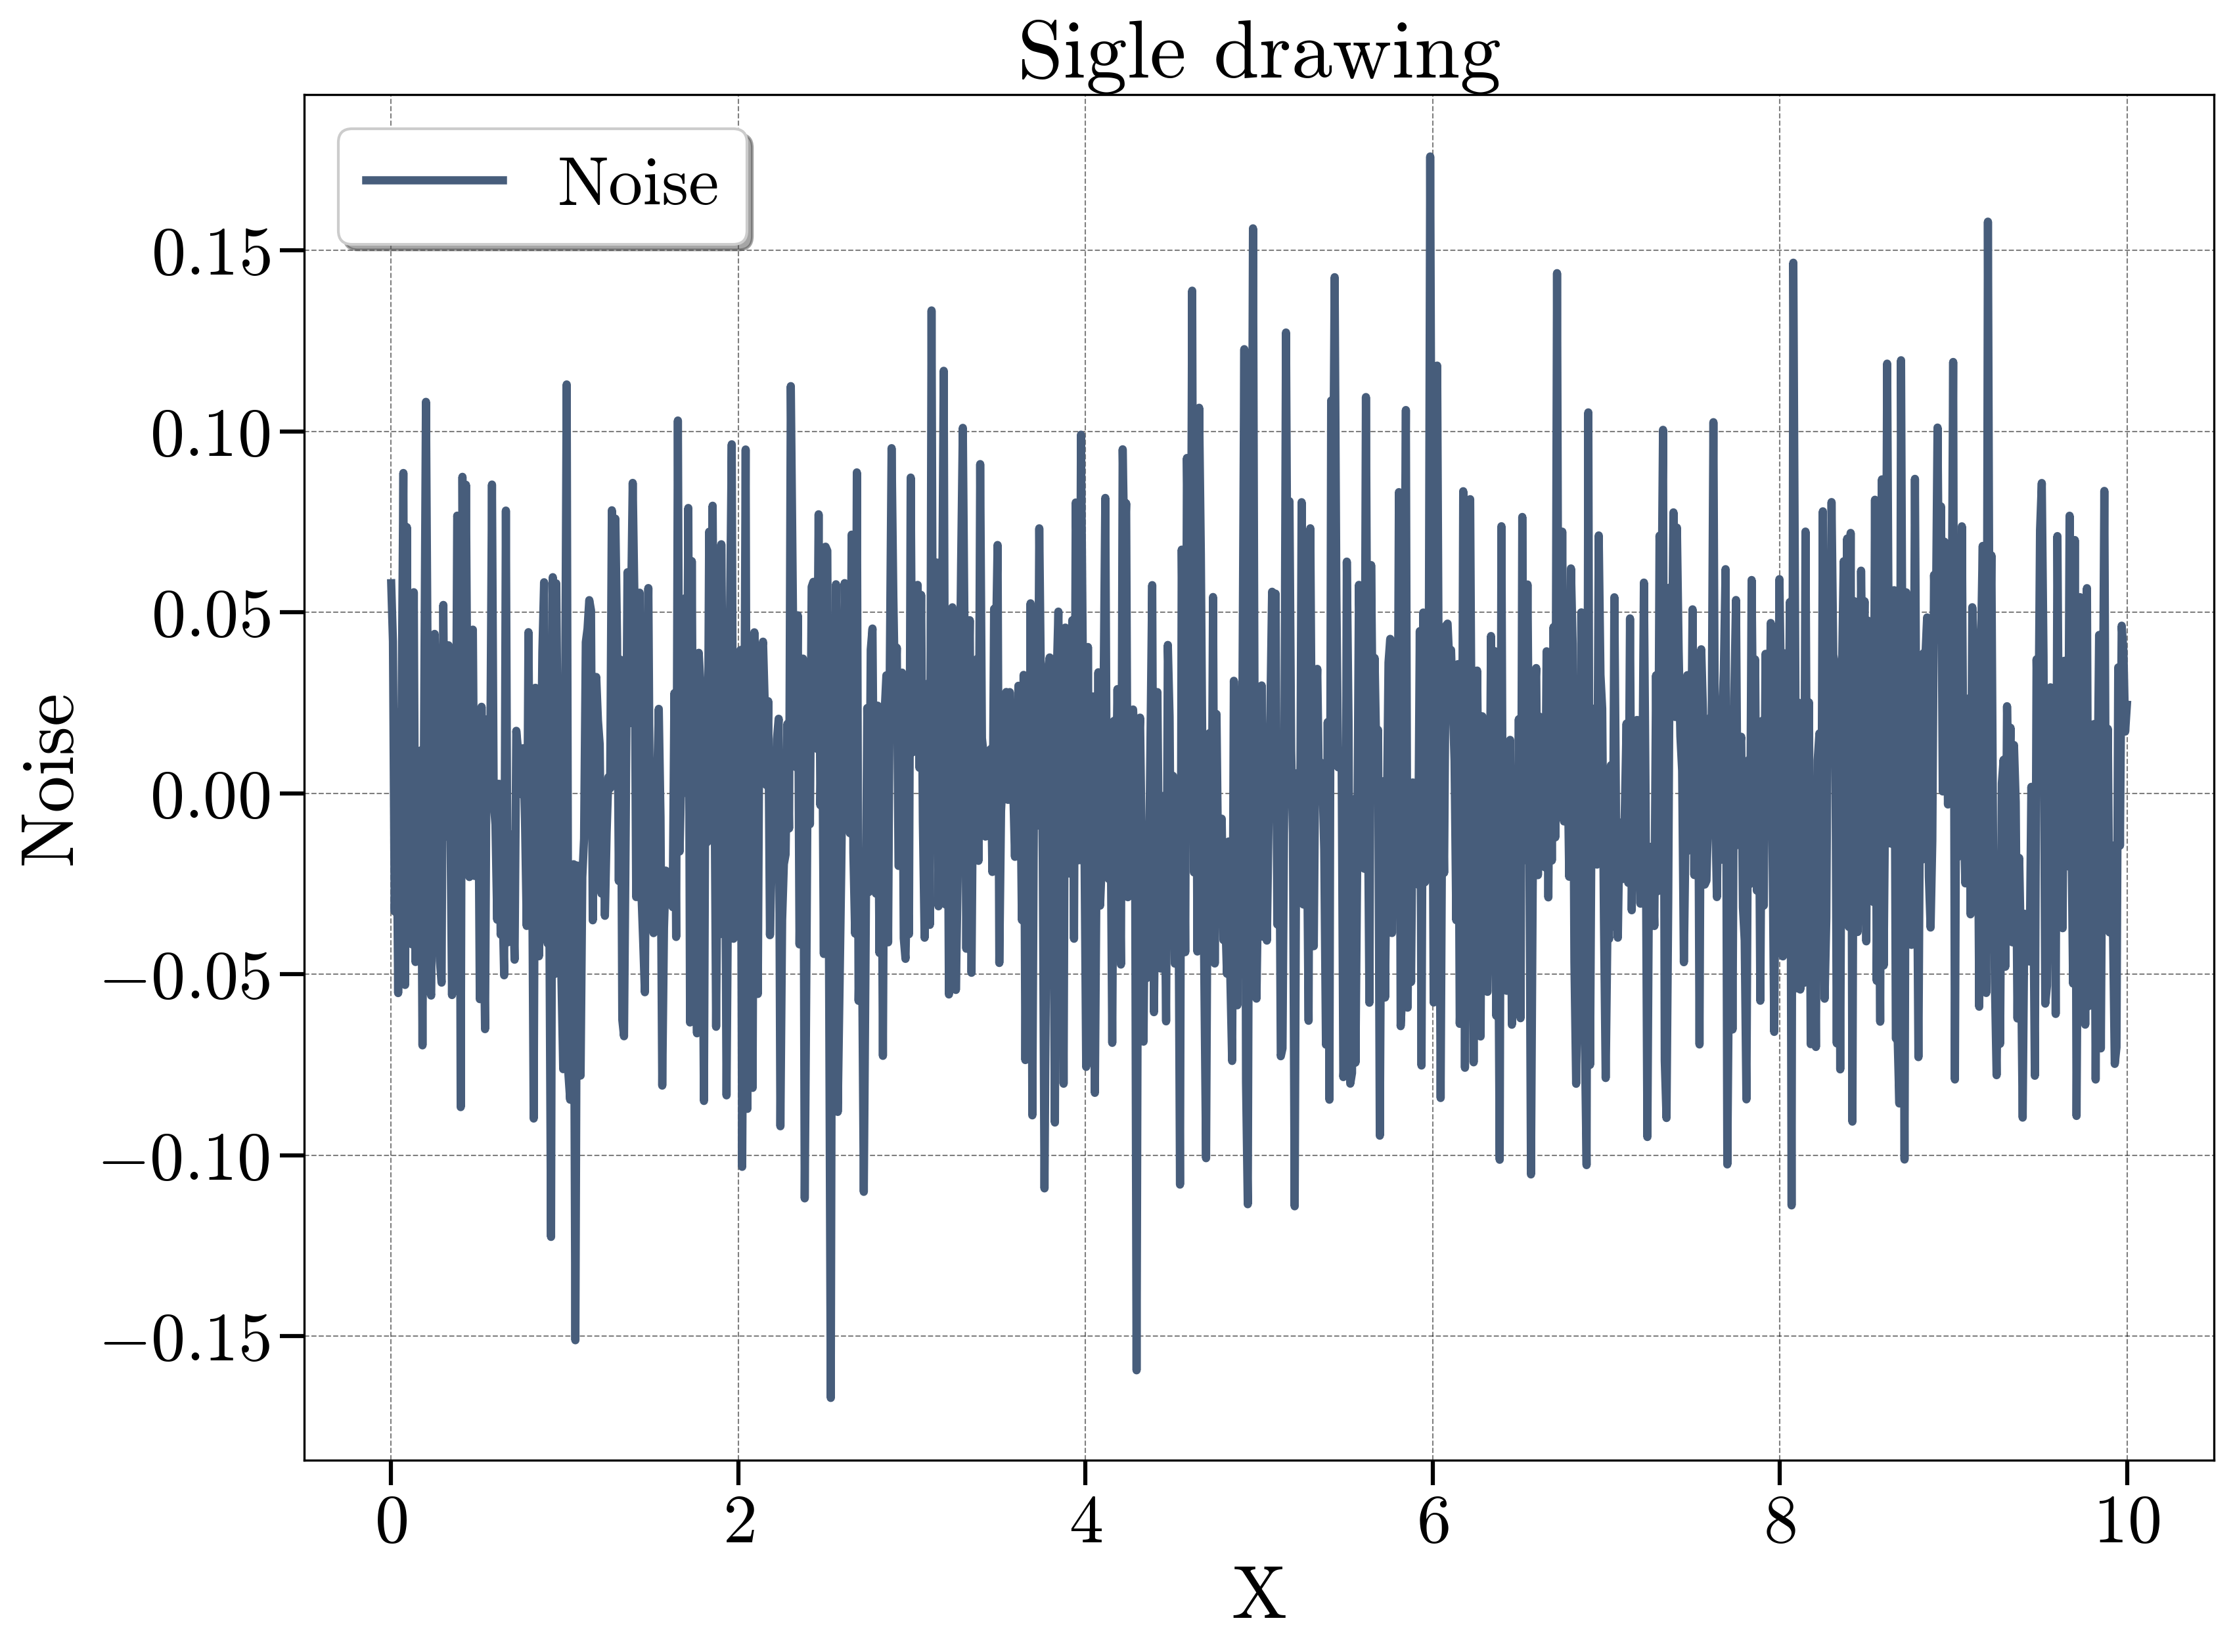

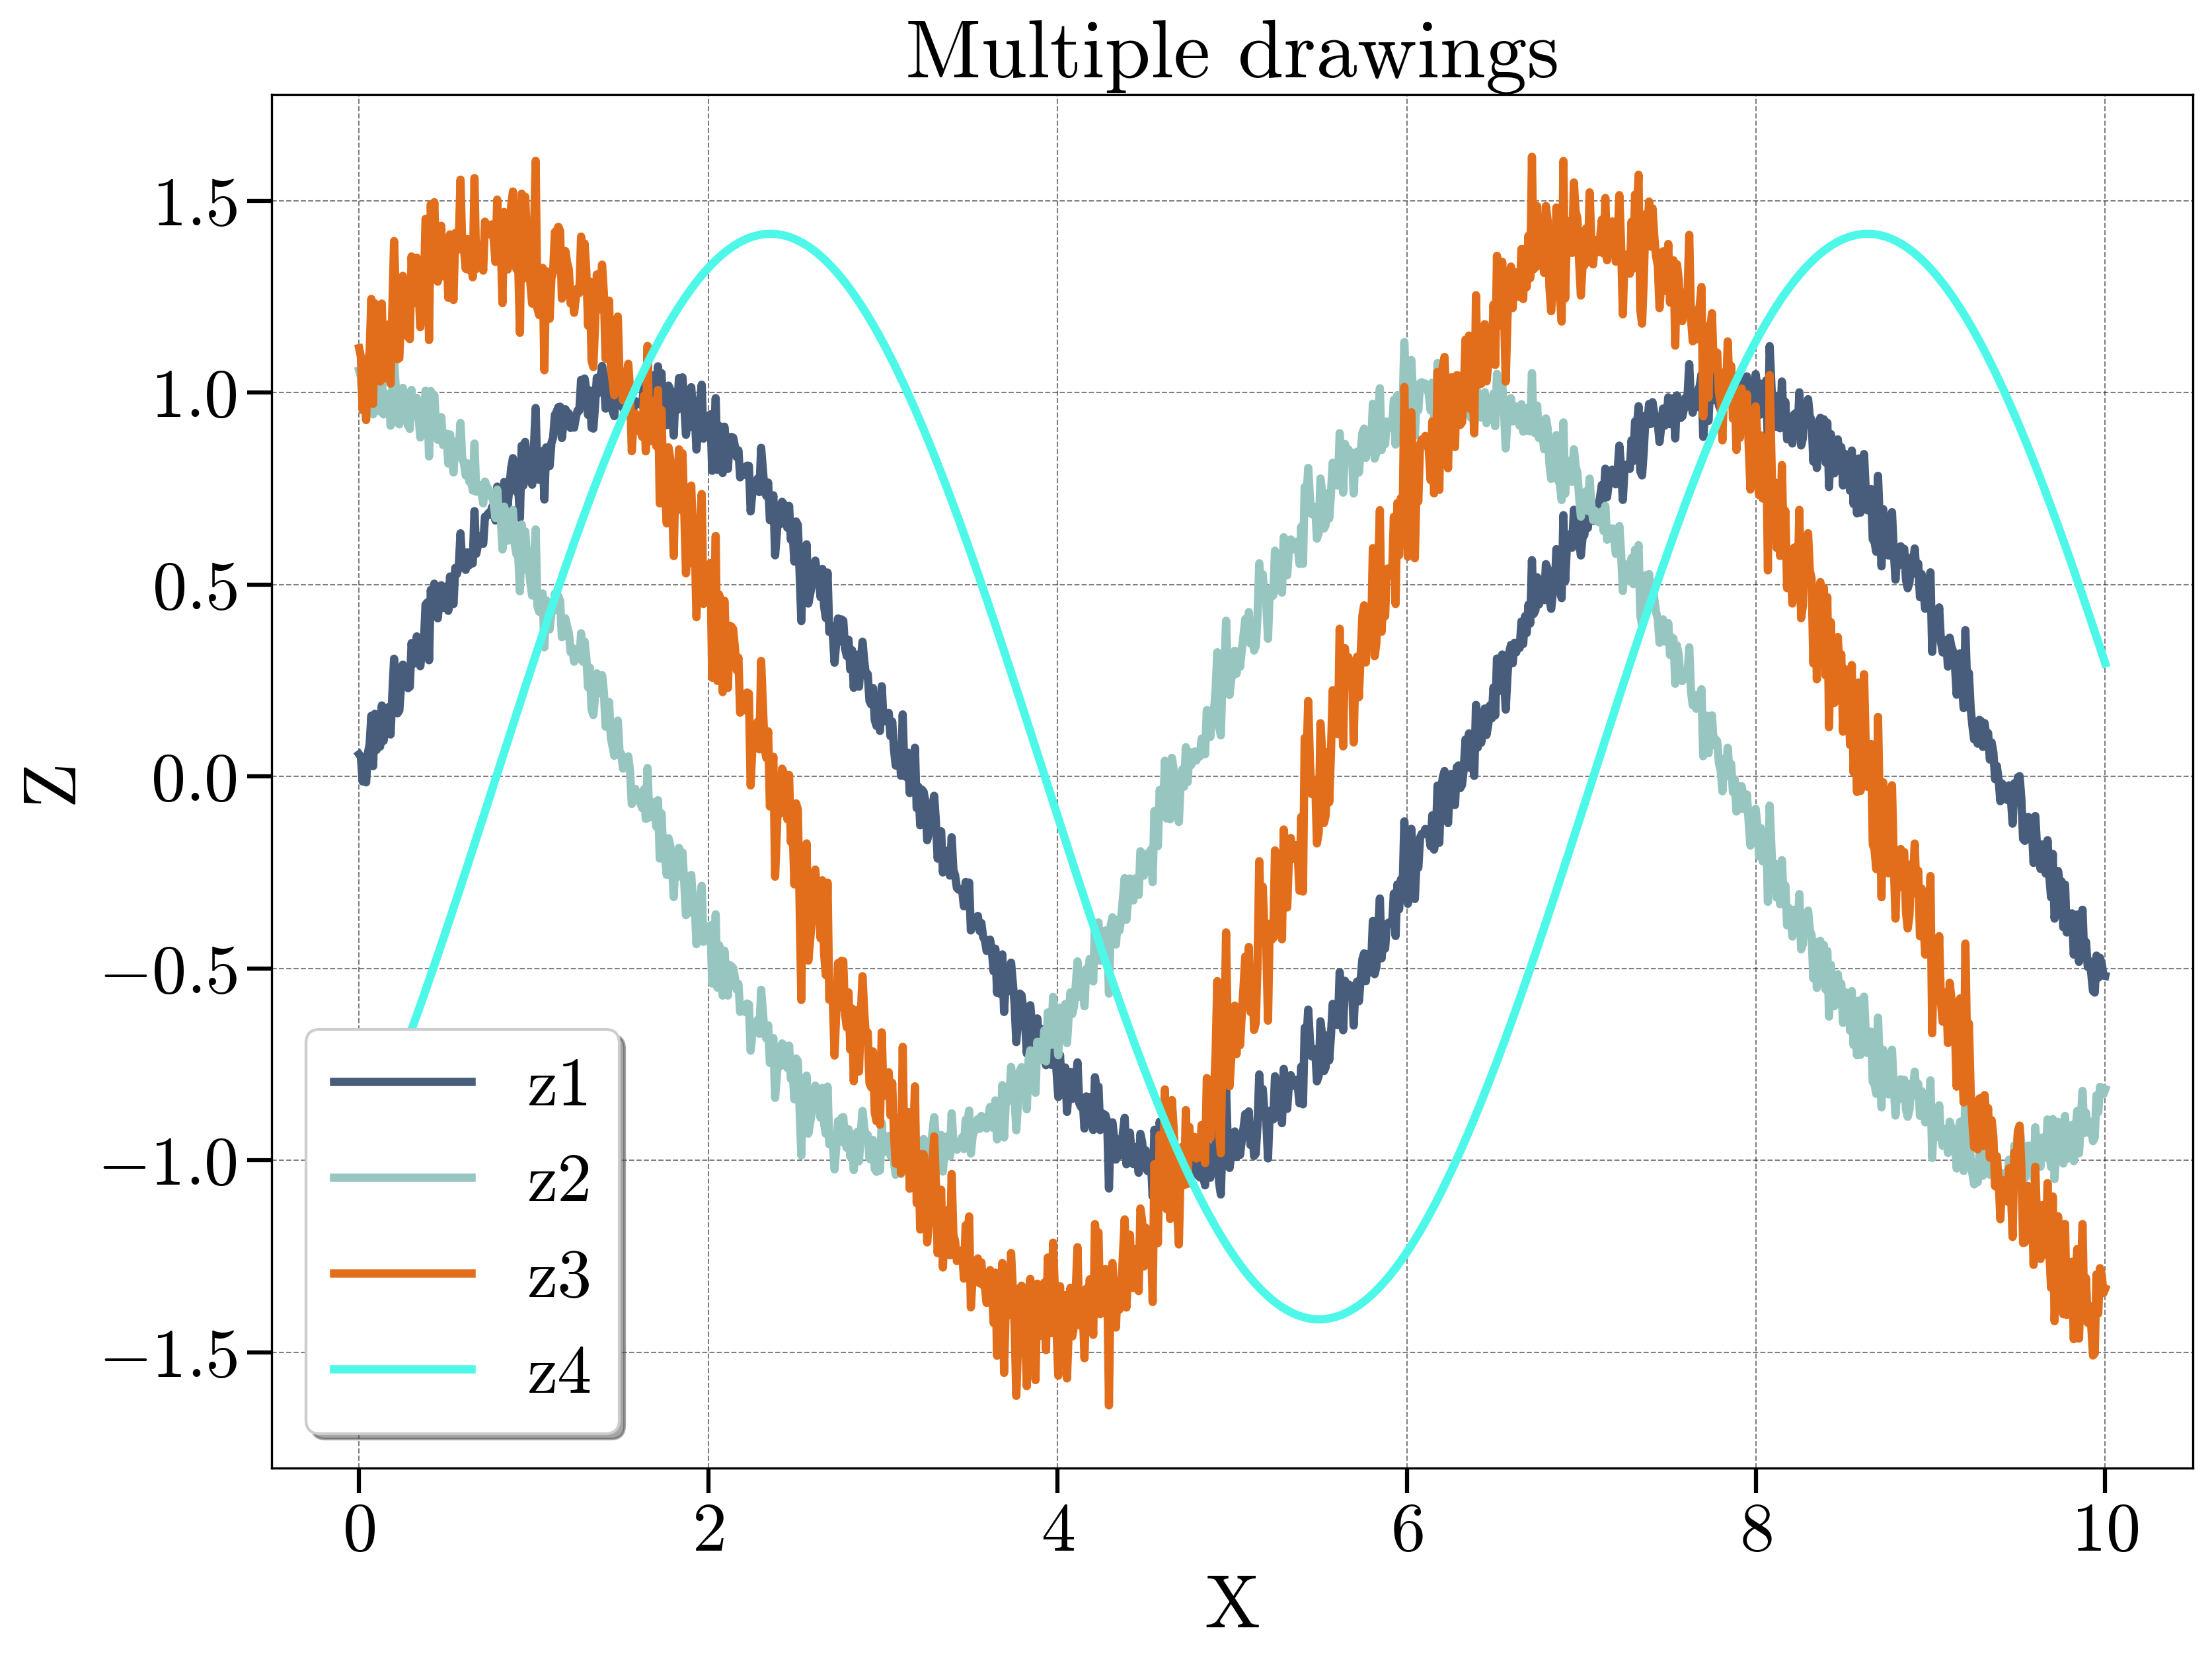

In [4]:
# ypu.plot使用示例

# 单一绘图
noise = np.random.normal(0, 0.05, len(x))
ypu.plot(x, noise, 'Noise', plot_title='Sigle drawing', y_label='Noise')

# 多个绘图
z1 = np.sin(x) + noise
z2 = np.cos(x) + noise
z3 = z1 + z2
z4 = z1 - z2
ypu.plot(x, (z1, z2, z3, z4), ('z1', 'z2', 'z3', 'z4'), plot_title='Multiple drawings', y_label='Z')

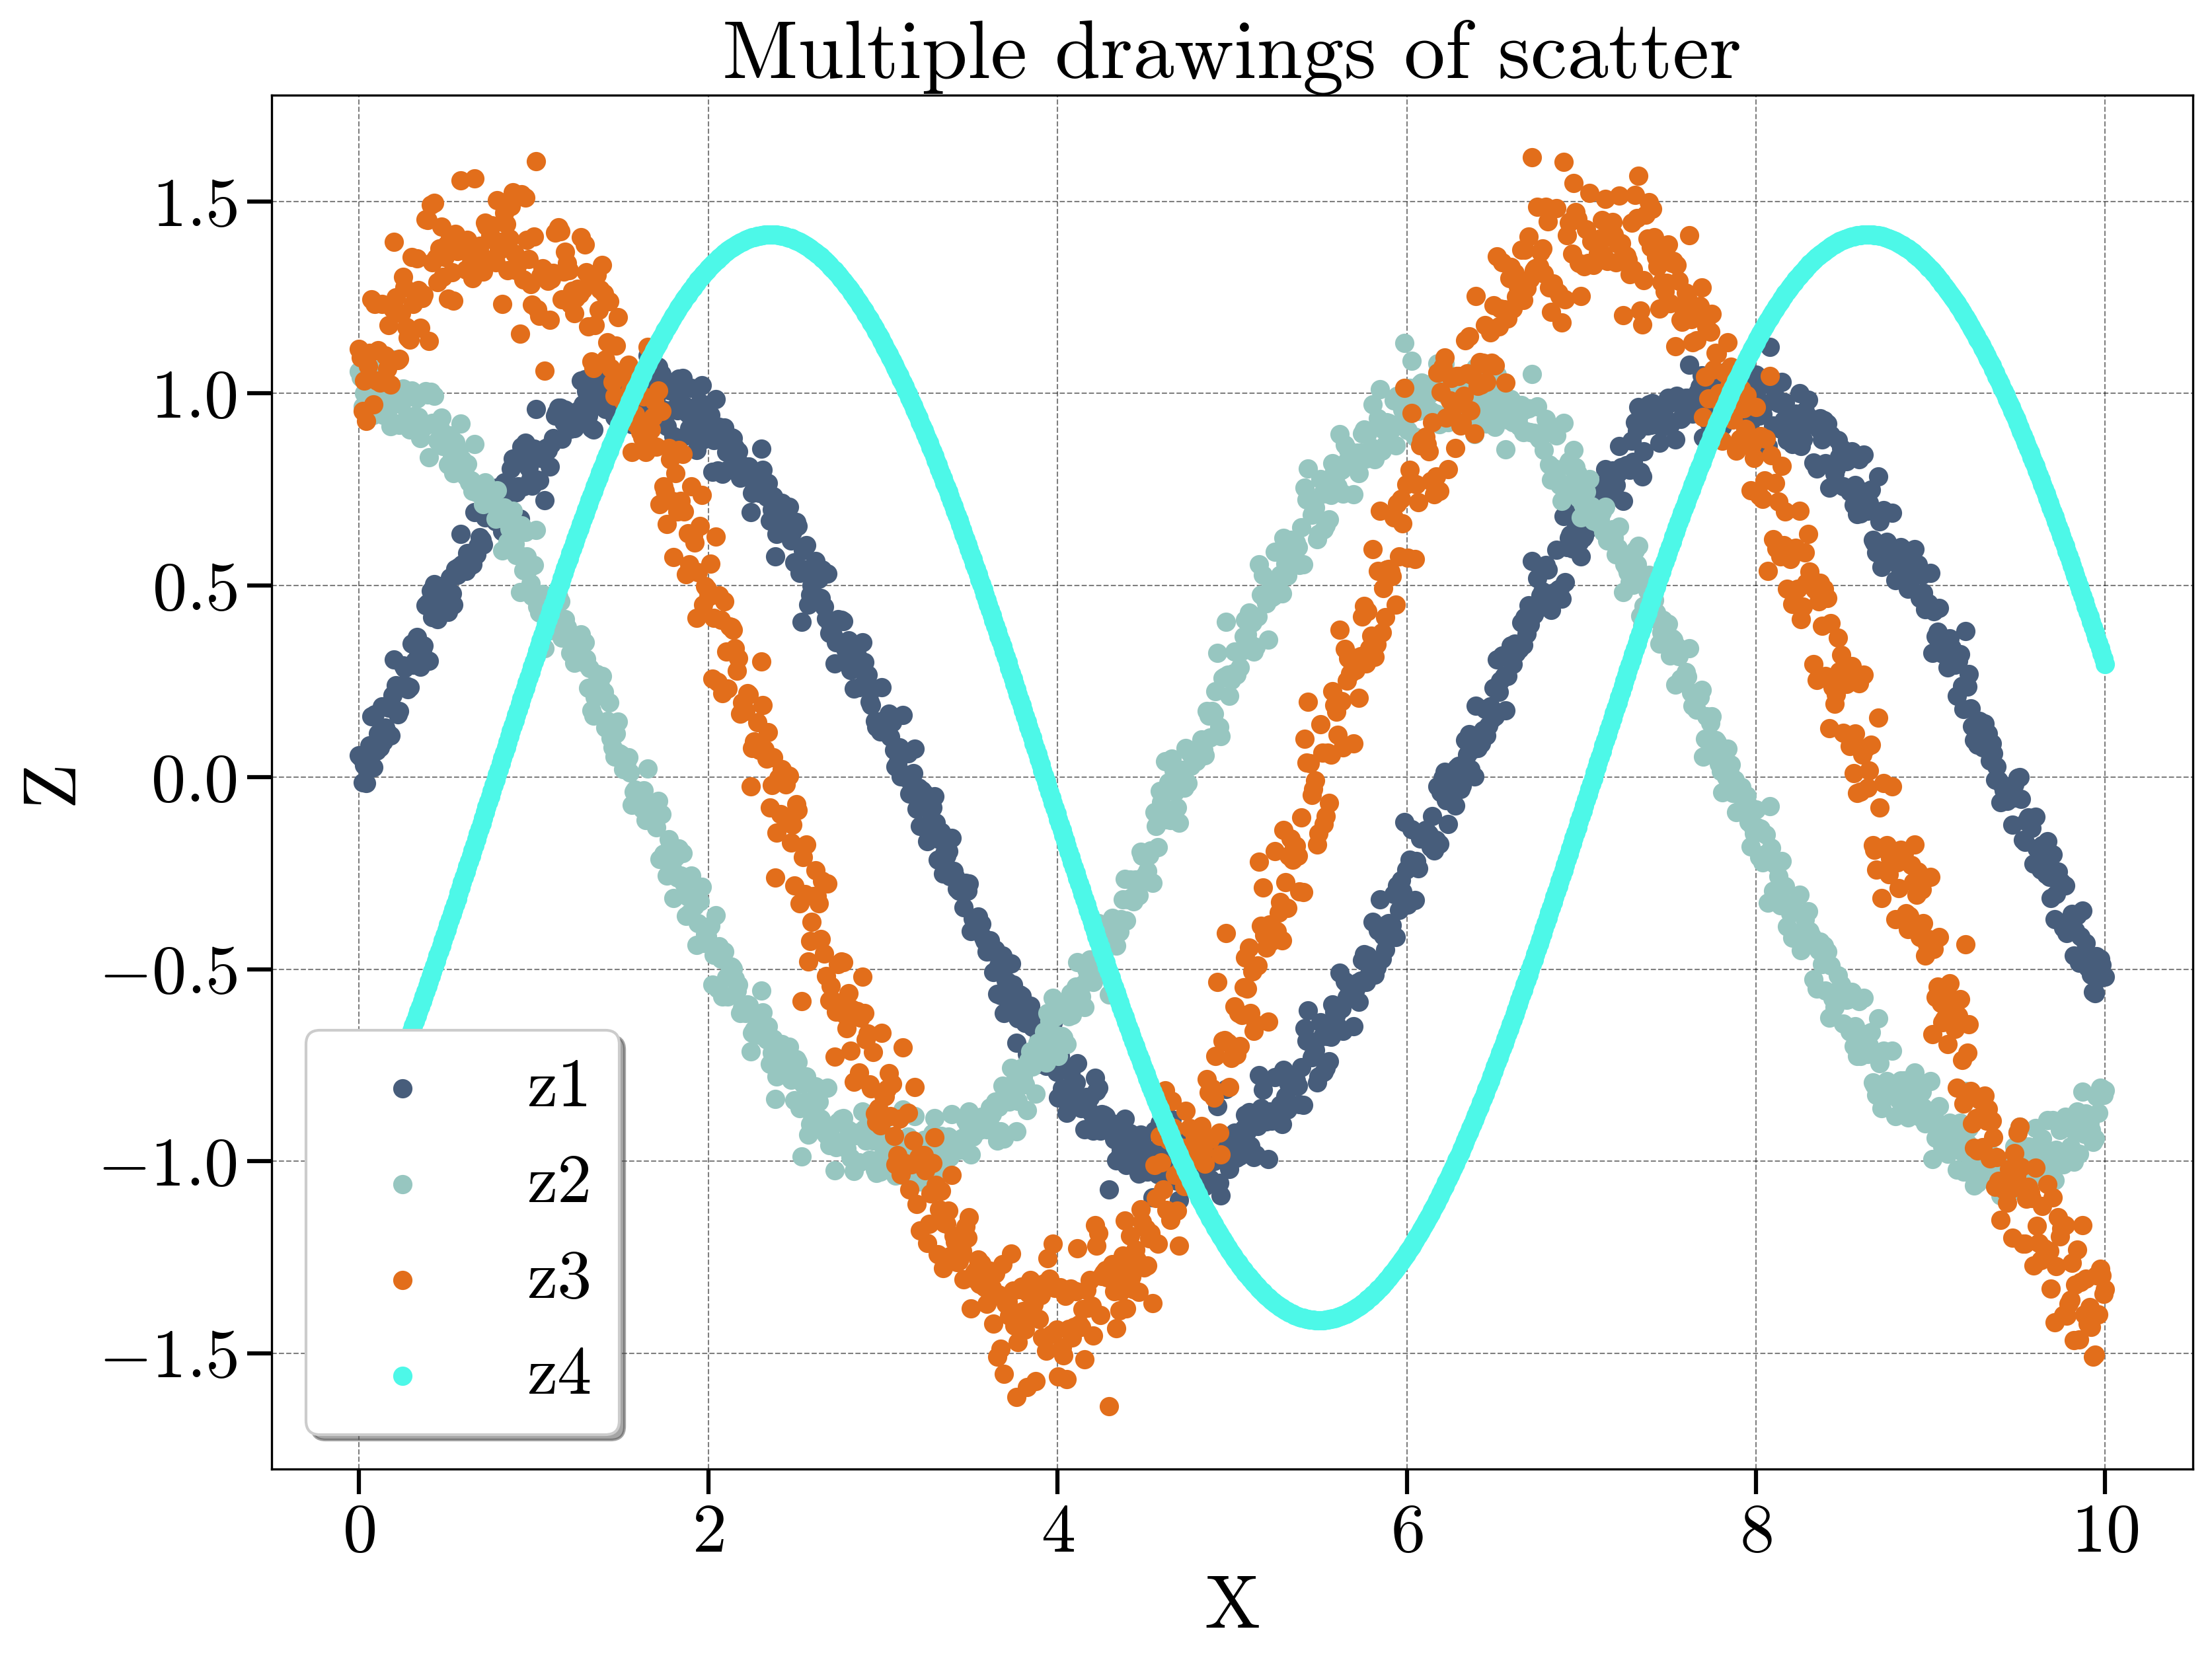

In [5]:
# 用ypu.plot绘制scatter
ypu.plot(x, (z1, z2, z3, z4), ('z1', 'z2', 'z3', 'z4'), plot_title='Multiple drawings of scatter', y_label='Z', plot_type='scatter')

## 1.2版本新增功能

1. 全新的流萤主题配色
2. 绘制数据点的功能

详见以下演示。

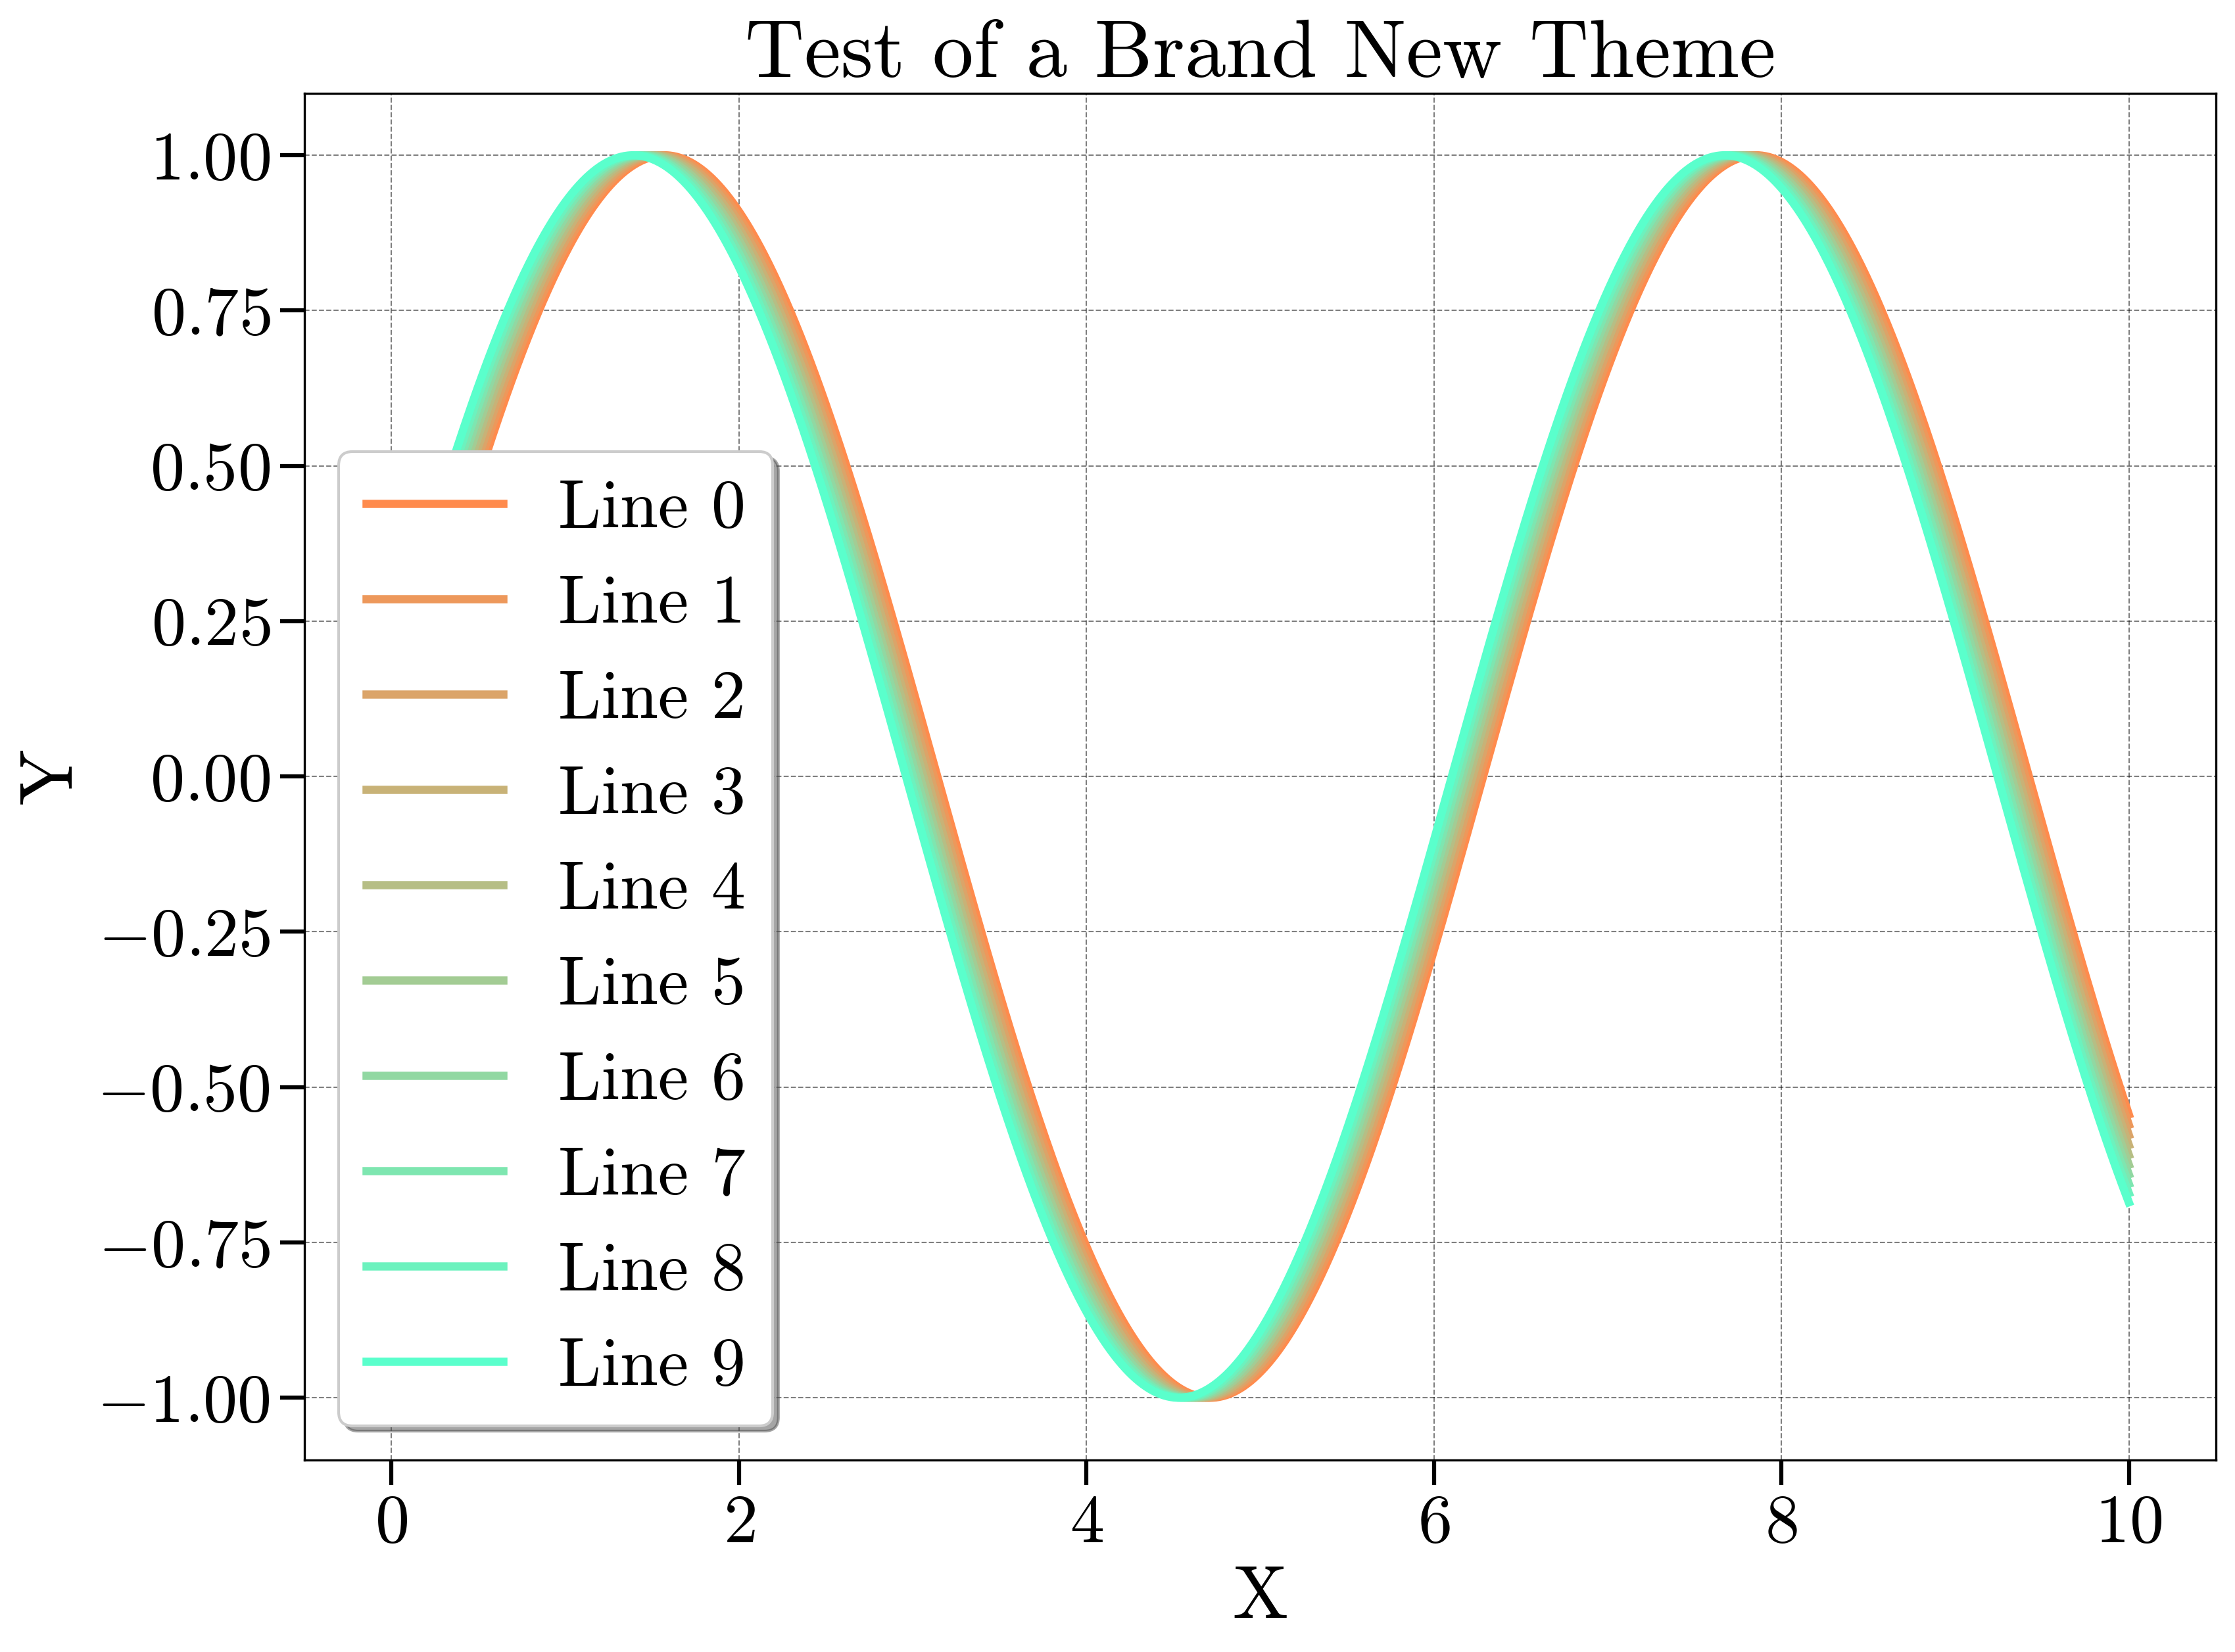

In [6]:
# 更新颜色设置并获得一个cmap
liuyin_cmap = ypu.liuyin_color_theme(cmap_or_cycle='cmap')

# 配色展示

ypu.plot(x, tuple(np.sin(x + 0.02 * i) for i in range(10)), tuple('Line ' + str(i) for i in range(10)), 'Test of a Brand New Theme')


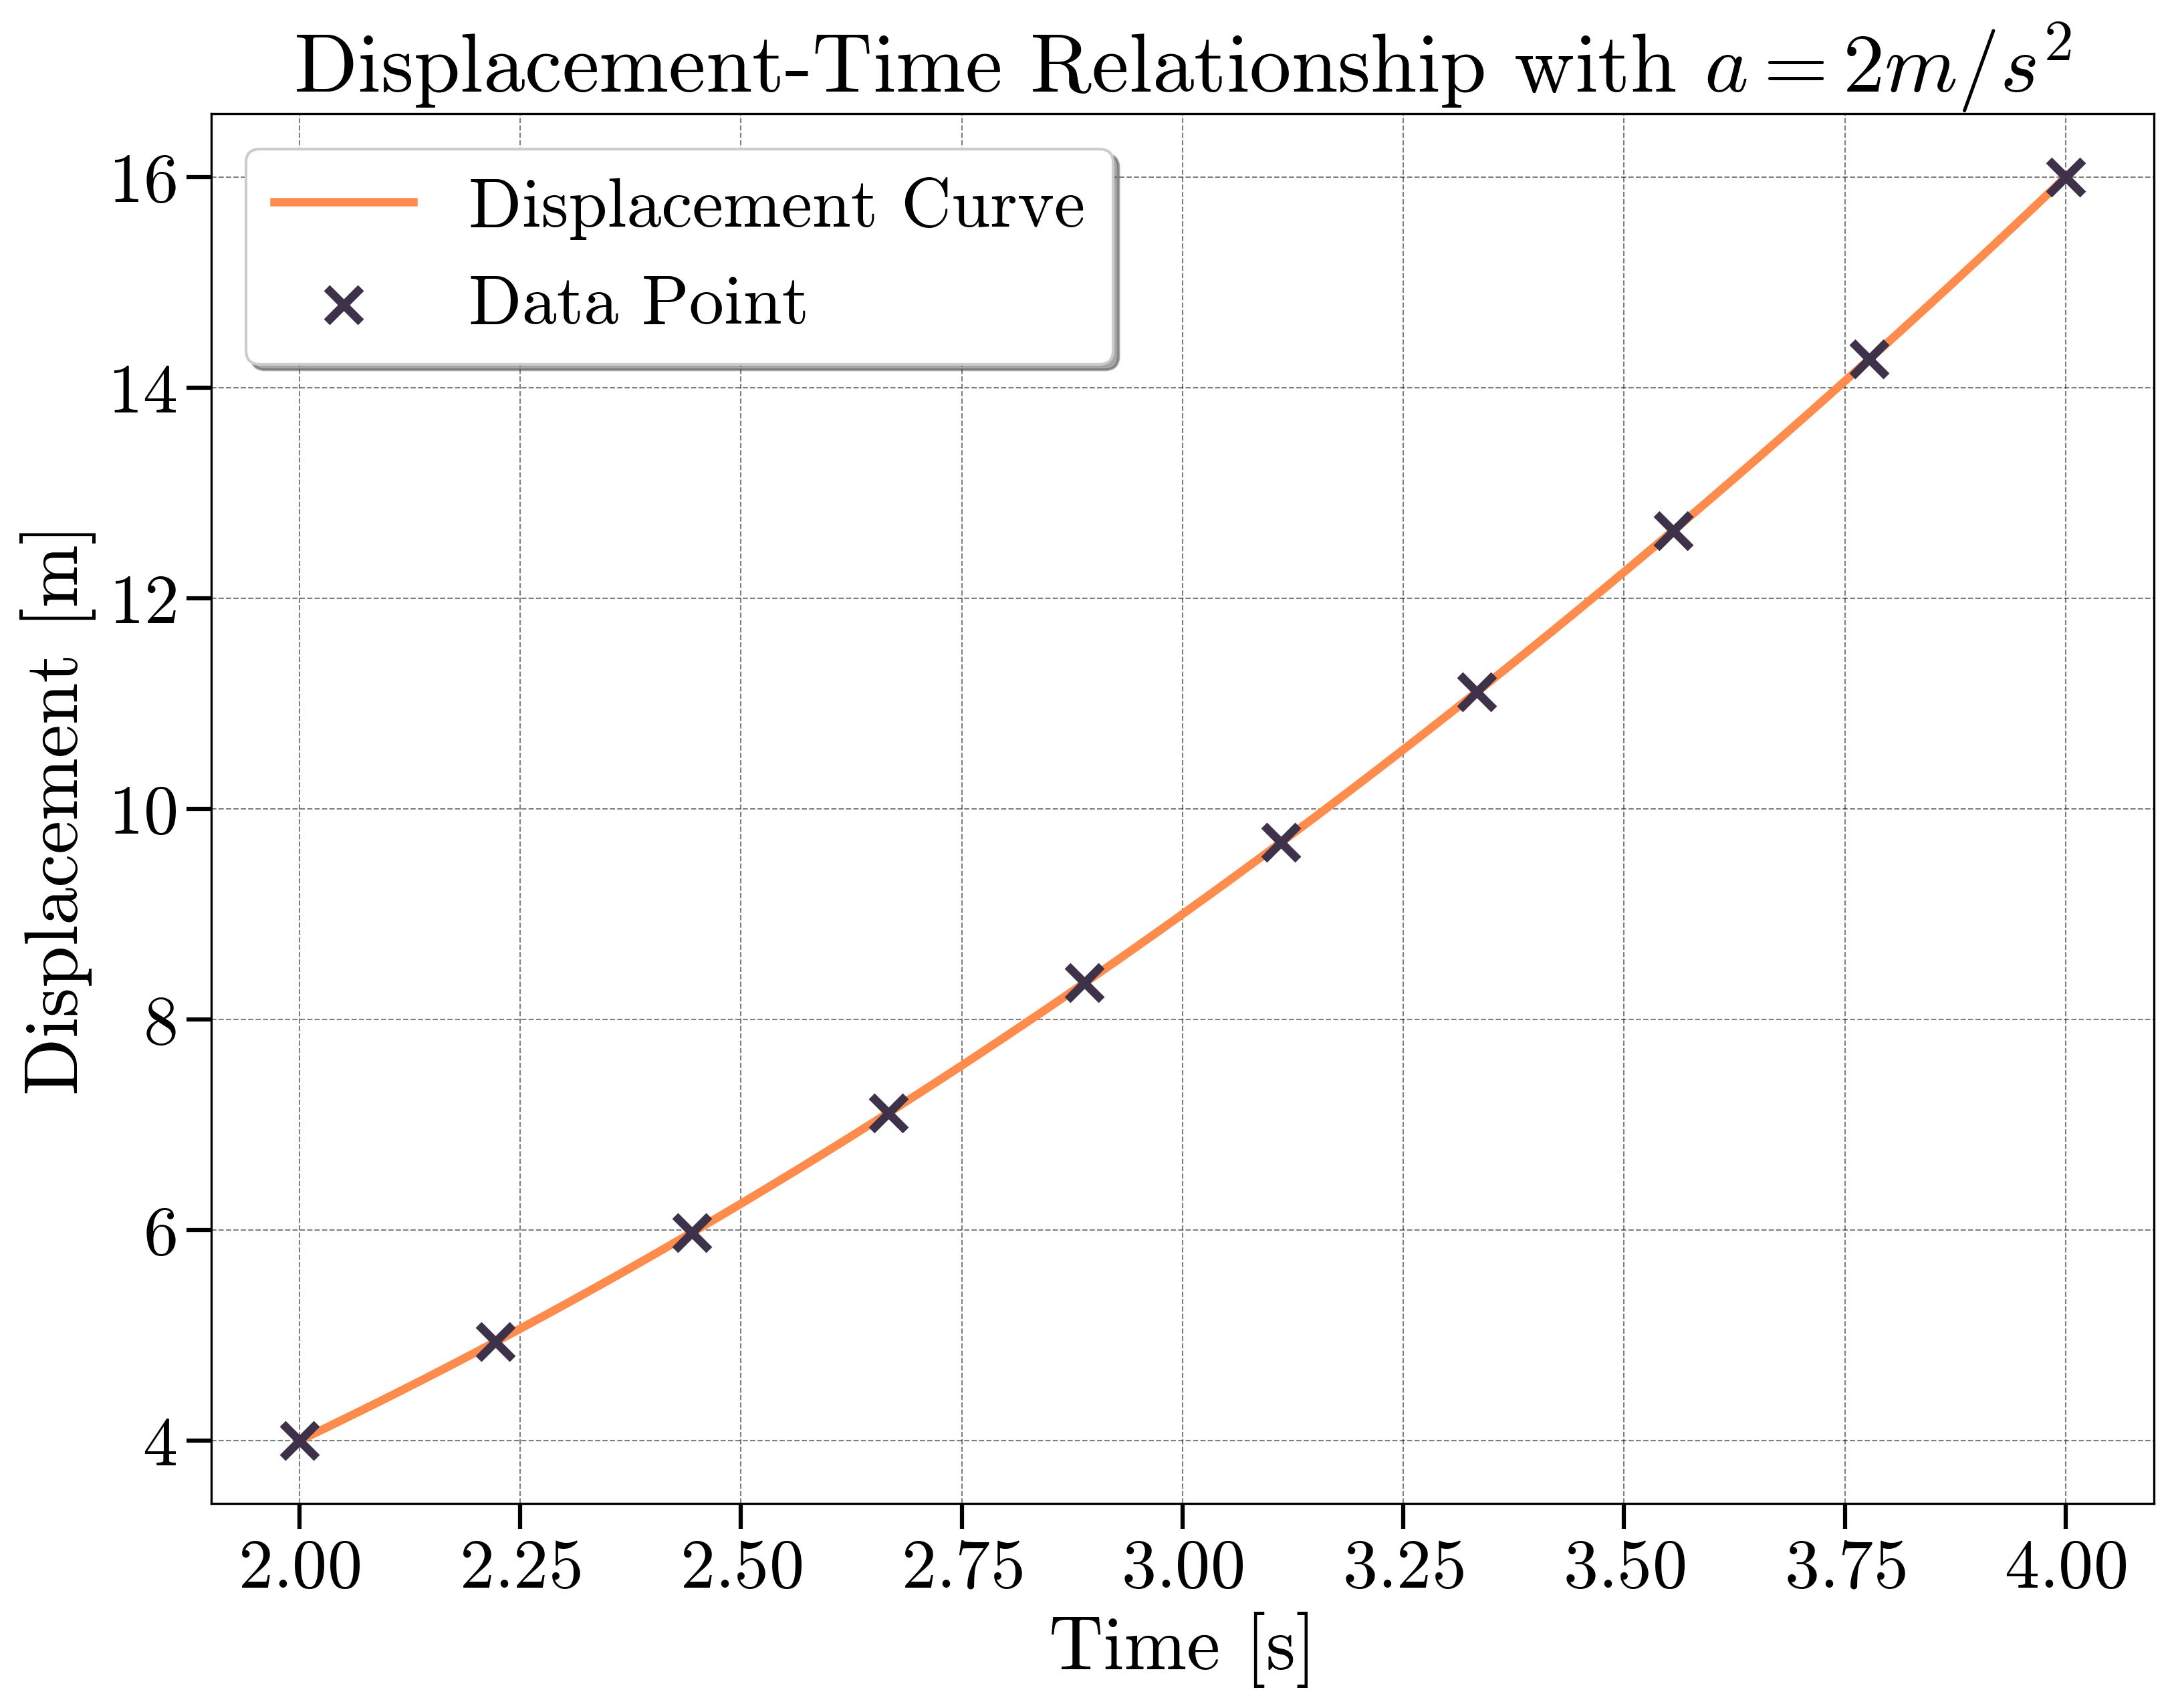

In [7]:
# 展示绘制数据点的功能
time = np.linspace(2, 4, 10)
displacement = time**2
velocity = 2 * time
time_fine = np.linspace(2, 4, 1000)
displace_fine = time_fine**2

ypu.plot(
    time_fine, displace_fine, 'Displacement Curve', 
    plot_title='Displacement-Time Relationship with $a=2m/s^2$', 
    data_point=(time, displacement), 
    x_label='Time [s]', 
    y_label='Displacement [m]'
)

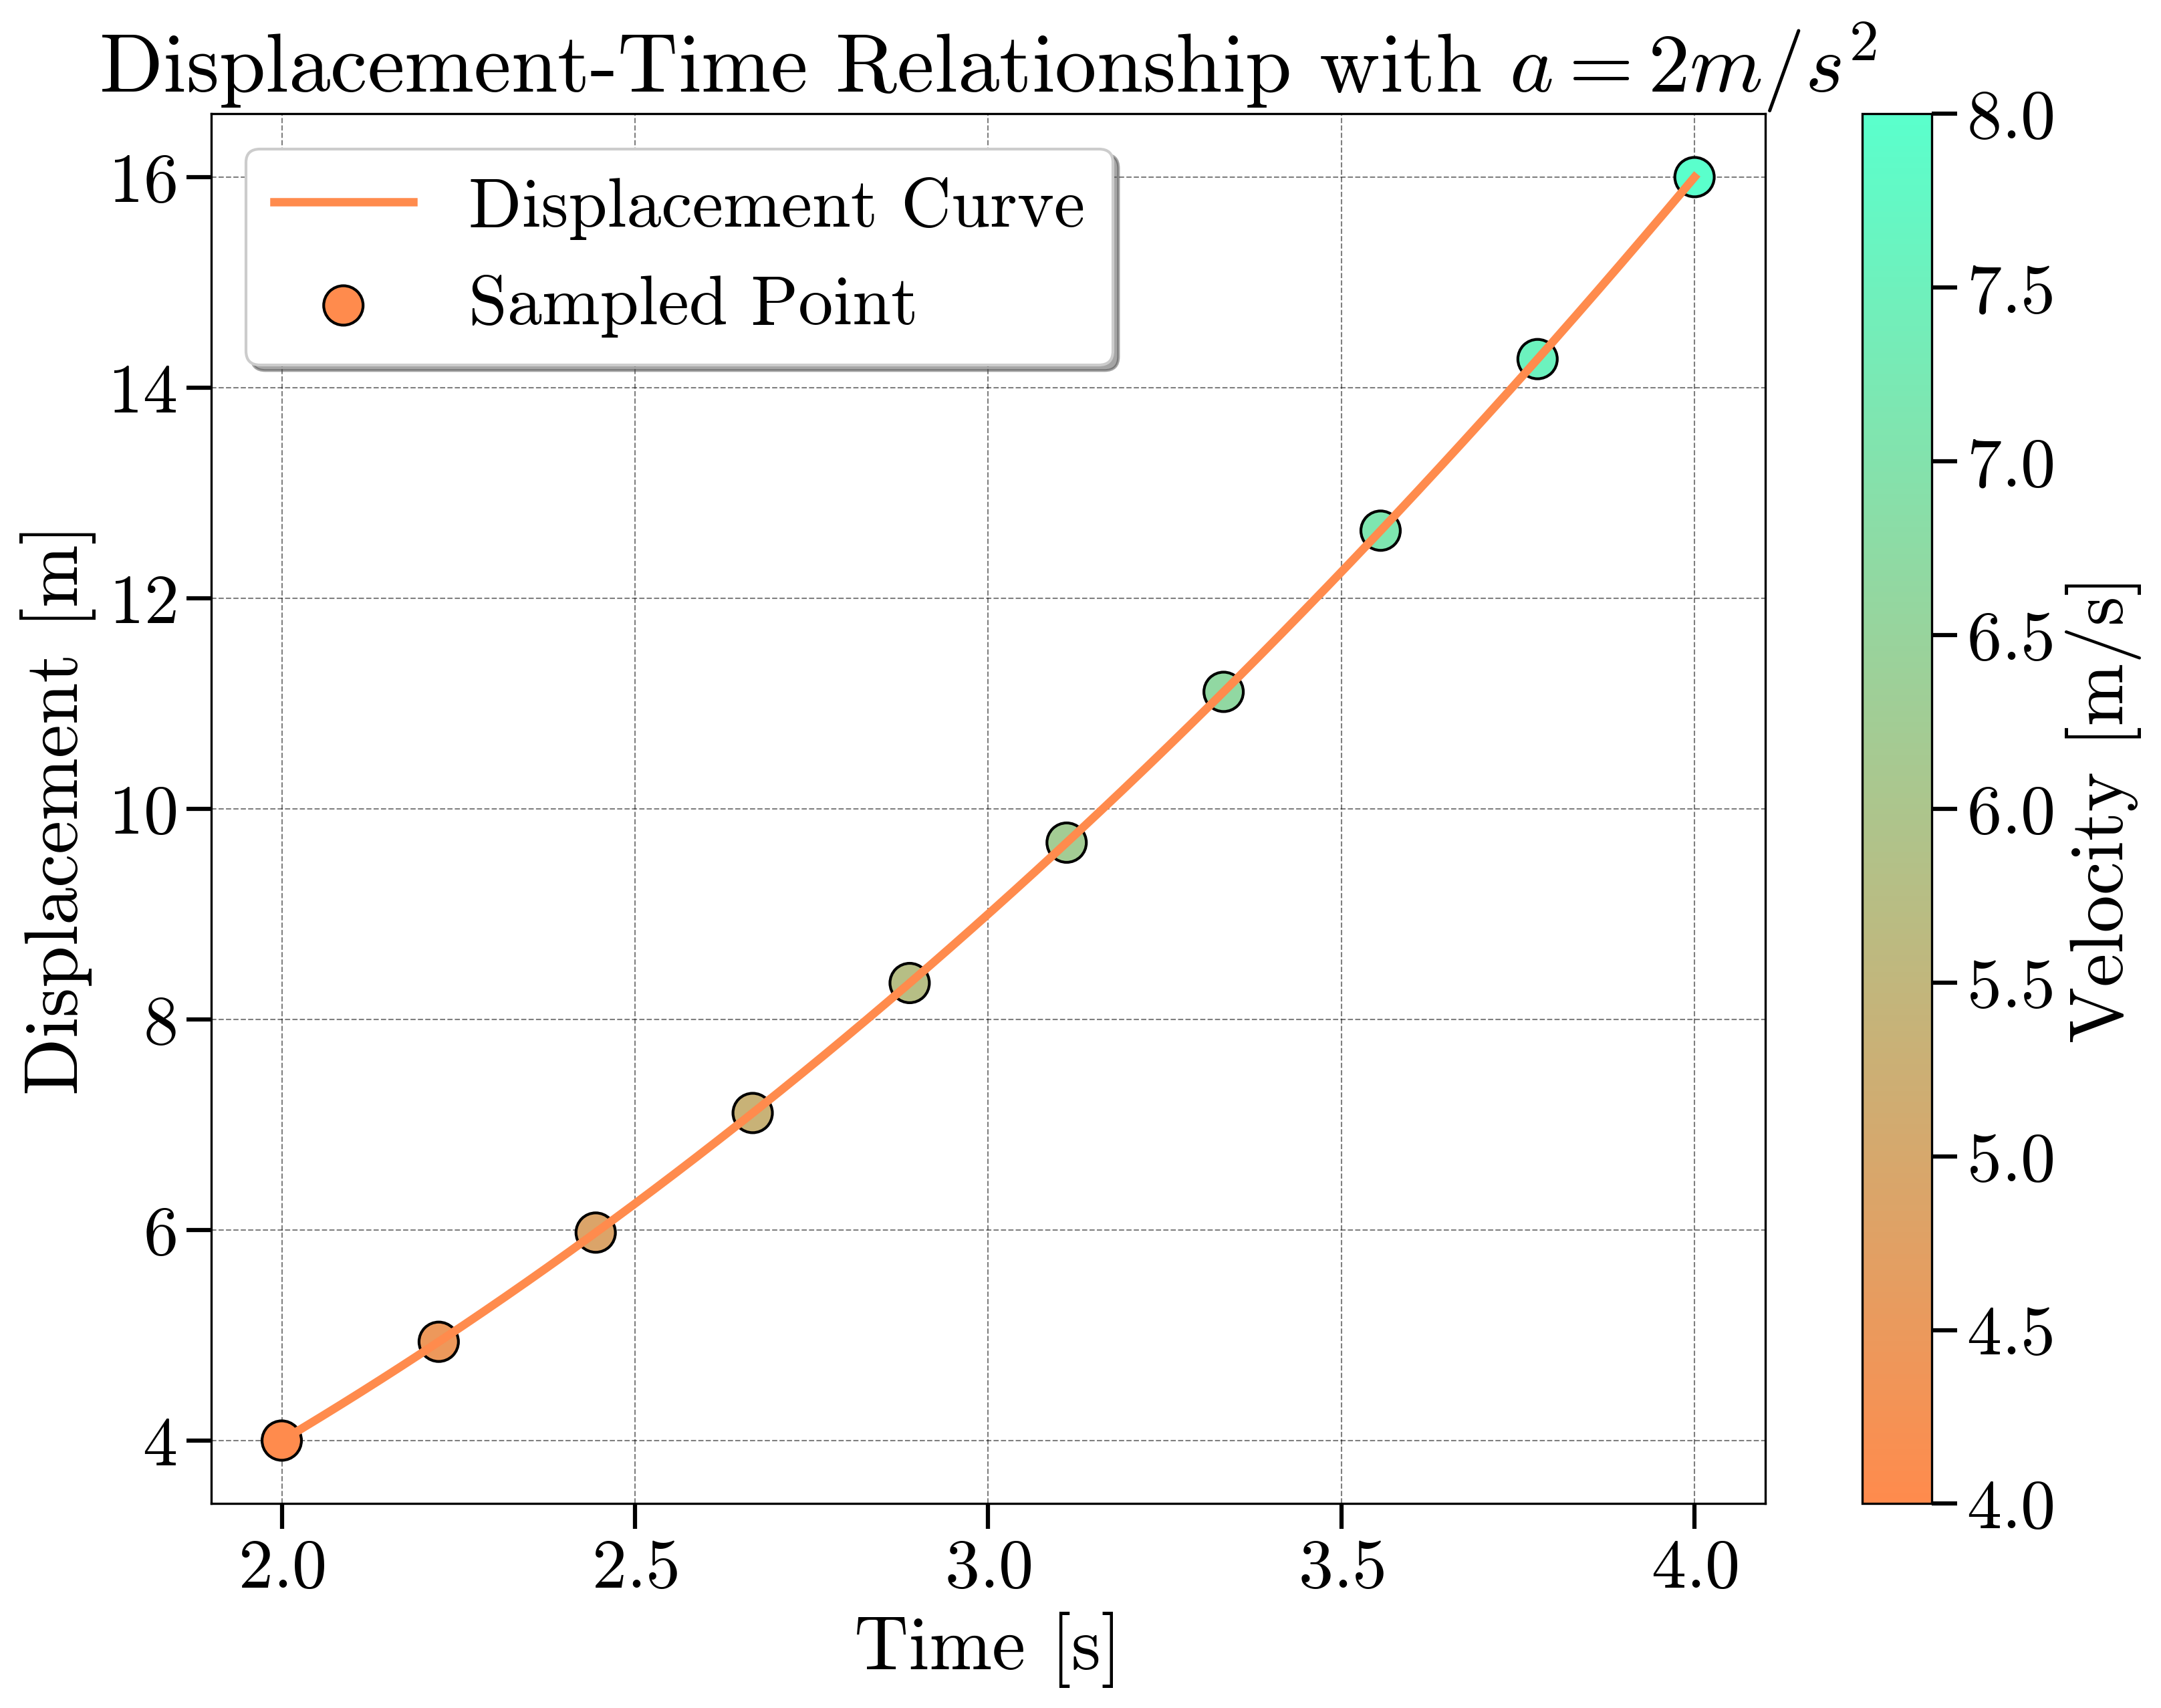

In [8]:
# 以下给出了绘制带colorbar的scatter的参考
plt.figure()
plt.plot(time_fine, displace_fine, label='Displacement Curve')
scatter_plot = plt.scatter(time, displacement, c=velocity, cmap=liuyin_cmap, s=200, edgecolor='black', label='Sampled Point')
plt.colorbar(scatter_plot, label='Velocity [m/s]')
plt.legend()
plt.xlabel('Time [s]')
plt.ylabel('Displacement [m]')
plt.title('Displacement-Time Relationship with $a=2m/s^2$')
plt.show()